# Feature engineering experiments

This notebook documents the experiments that led to the final time- and frequency-domain feature set. It covers window extraction, dataset preparation, condition summaries, and challenge recordings.

> **Pipeline note:** Some cells intentionally preserve earlier iterations for comparison. The deduplicated implementation used by the command-line workflow lives in `src/machine_sentinel/features.py` and `src/machine_sentinel/datasets.py`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
SAMPLE_RATE = 200
WINDOW_SIZE = 200       # 1 second
COUNTS_PER_G = 4096.0   # MPU6050 at ±8g

In [3]:
def band_power(frequencies, power, low, high):

    mask = (
        (frequencies >= low) &
        (frequencies < high)
    )

    return np.sum(power[mask])

In [4]:
def extract_window_features(
    window_data,
    sample_rate=SAMPLE_RATE
):
    """
    Extract vibration features from one fixed-size window.
    """

    # ---------------------------------
    # 1. Raw counts -> acceleration (g)
    # ---------------------------------

    ax = window_data["ax"].to_numpy() / COUNTS_PER_G
    ay = window_data["ay"].to_numpy() / COUNTS_PER_G
    az = window_data["az"].to_numpy() / COUNTS_PER_G

    # ---------------------------------
    # 2. Remove DC / gravity
    # ---------------------------------

    ax_c = ax - np.mean(ax)
    ay_c = ay - np.mean(ay)
    az_c = az - np.mean(az)

    # ---------------------------------
    # 3. Time-domain features
    # ---------------------------------

    dynamic_mag = np.sqrt(
        ax_c**2 +
        ay_c**2 +
        az_c**2
    )

    # Overall 3-axis vibration strength
    rms = np.sqrt(
        np.mean(
            ax_c**2 +
            ay_c**2 +
            az_c**2
        )
    )

    # Spread of vector vibration magnitude
    ptp = np.ptp(dynamic_mag)

    # ---------------------------------
    # 4. FFT each axis separately
    # ---------------------------------

    fft_x = np.fft.rfft(ax_c)
    fft_y = np.fft.rfft(ay_c)
    fft_z = np.fft.rfft(az_c)

    frequencies = np.fft.rfftfreq(
        len(ax_c),
        d=1 / sample_rate
    )

    # ---------------------------------
    # 5. Combine spectral power
    # ---------------------------------

    power = (
        np.abs(fft_x) ** 2 +
        np.abs(fft_y) ** 2 +
        np.abs(fft_z) ** 2
    )

    # Ignore 0 Hz
    dominant_idx = np.argmax(power[1:]) + 1

    dominant_freq = frequencies[dominant_idx]

    # ---------------------------------
    # 6. Band energy
    # ---------------------------------

    energy_low = band_power(
        frequencies,
        power,
        1,
        30
    )

    energy_mid = band_power(
        frequencies,
        power,
        30,
        50
    )

    energy_high = band_power(
        frequencies,
        power,
        50,
        101
    )

    return {
        "rms": rms,
        "ptp": ptp,
        "dominant_freq": dominant_freq,
        "energy_low": energy_low,
        "energy_mid": energy_mid,
        "energy_high": energy_high
    }

In [5]:
def extract_recording_features(df, recording_id, condition, label, window_size=WINDOW_SIZE):
    """
    Extract DSP features from a recording of accelerometer data.

    Parameters:
        df (pd.DataFrame):
            DataFrame containing accelerometer data for multiple recordings.
        recording_id (int):
            ID of the recording to extract features from.
        condition (str):
            Condition under which the recording was made.
        label (int):
            Label for the recording.
        window_size (int):
            Size of the window in samples.
        sample_rate (int):
            Sampling frequency in Hz.

    Returns:
        dict:
            Extracted features for the recording.
    """
    rows = []
    for start in range(0, len(df), window_size):
        end = start + window_size

        if end > len(df):
            break

        window_data = df.iloc[start:end]
        features = extract_window_features(window_data)
        rows.append({
            "recording_id": recording_id,
            "condition": condition,
            "label": label,
            "start_time_s": start / SAMPLE_RATE,
            "window" : start // window_size,
            **features
        })

    return pd.DataFrame(rows)

In [6]:
df = pd.read_csv("../../data/raw/40hz.csv")

In [7]:
features = extract_recording_features(df, recording_id="normal_40_01", condition="normal_40hz", label=0)

In [8]:
features.head()

,recording_id,condition,label,start_time_s,window,rms,ptp,dominant_freq,energy_low,energy_mid,energy_high
0,normal_40_01,normal_40hz,0,0.0,0,0.113797,0.126300,40.0,0.545088,234.419818,24.031180
1,normal_40_01,normal_40hz,0,1.0,1,0.113035,0.129577,40.0,0.378028,225.966346,29.195398
2,normal_40_01,normal_40hz,0,2.0,2,0.113095,0.129567,40.0,0.488597,227.868842,27.456044
3,normal_40_01,normal_40hz,0,3.0,3,0.114214,0.119420,40.0,0.500310,239.617217,20.779037
4,normal_40_01,normal_40hz,0,4.0,4,0.116930,0.119435,40.0,0.208243,259.633274,13.610555


In [9]:
# DATA 

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
SAMPLE_RATE = 200
WINDOW_SIZE = 200
COUNTS_PER_G = 4096.0

In [12]:
def extract_recording_features(
    df,
    recording_id,
    condition,
    label,
    trim_seconds=1
):
    """
    Convert one complete recording into one feature row
    per 1-second window.
    """

    df = df.copy()

    # ---------------------------------------
    # Remove start/stop transient regions
    # ---------------------------------------

    trim_samples = int(trim_seconds * SAMPLE_RATE)

    if len(df) > 2 * trim_samples:
        df = df.iloc[
            trim_samples : len(df) - trim_samples
        ].reset_index(drop=True)

    rows = []

    # ---------------------------------------
    # Split recording into windows
    # ---------------------------------------

    for start in range(
        0,
        len(df),
        WINDOW_SIZE
    ):

        end = start + WINDOW_SIZE

        # Ignore incomplete final window
        if end > len(df):
            break

        window_data = df.iloc[start:end]

        features = extract_window_features(
            window_data,
            SAMPLE_RATE
        )

        rows.append({
            "recording_id": recording_id,
            "condition": condition,
            "label": label,

            "window": start // WINDOW_SIZE,
            "start_time_s": start / SAMPLE_RATE,

            "rms": features["rms"],
            "ptp": features["ptp"],
            "dominant_freq": features["dominant_freq"],

            "energy_low": features["energy_low"],
            "energy_mid": features["energy_mid"],
            "energy_high": features["energy_high"]
        })

    return pd.DataFrame(rows)

In [13]:
DATA_DIR = Path("../../data/raw/final")
conditions = {
    "normal_40": {
        "folder": DATA_DIR / "normal_40",
        "label": 0
    },

    "loud_40": {
        "folder": DATA_DIR / "loud_40",
        "label": 1
    },

    "freq_60": {
        "folder": DATA_DIR / "freq_60",
        "label": 1
    }
}

In [14]:
all_feature_tables = []

for condition, config in conditions.items():

    folder = config["folder"]
    label = config["label"]

    files = sorted(folder.glob("*.csv"))

    print(
        condition,
        "->",
        len(files),
        "files"
    )

    for file_path in files:

        print("Processing:", file_path.name)

        df = pd.read_csv(file_path)

        # Safety check
        required_columns = {
            "ax",
            "ay",
            "az"
        }

        if not required_columns.issubset(df.columns):
            print(
                "Skipping:",
                file_path.name,
                "- missing accelerometer columns"
            )
            continue

        feature_df = extract_recording_features(
            df=df,
            recording_id=file_path.stem,
            condition=condition,
            label=label,
            trim_seconds=1
        )

        all_feature_tables.append(
            feature_df
        )

normal_40 -> 3 files
Processing: normal_40_1.csv
Processing: normal_40_2.csv
Processing: normal_40_3.csv
loud_40 -> 3 files
Processing: loud_40_1.csv
Processing: loud_40_2.csv
Processing: loud_40_3.csv
freq_60 -> 3 files
Processing: freq_60_1.csv
Processing: freq_60_2.csv
Processing: freq_60_3.csv


In [15]:
features_df = pd.concat(
    all_feature_tables,
    ignore_index=True
)

In [16]:
print(features_df.shape, "feature rows extracted")

(111, 11) feature rows extracted


In [17]:
print(features_df.head())

  recording_id  condition  label  window  start_time_s       rms       ptp  \
0  normal_40_1  normal_40      0       0           0.0  0.116593  0.149077   
1  normal_40_1  normal_40      0       1           1.0  0.114810  0.151654   
2  normal_40_1  normal_40      0       2           2.0  0.114264  0.152319   
3  normal_40_1  normal_40      0       3           3.0  0.112458  0.147915   
4  normal_40_1  normal_40      0       4           4.0  0.111741  0.143814   

   dominant_freq  energy_low  energy_mid  energy_high  
0           40.0    0.501665  247.152999    24.224718  
1           40.0    0.362661  237.020075    26.245325  
2           40.0    0.561556  231.920111    28.644940  
3           40.0    0.380671  223.349573    29.207585  
4           40.0    0.341503  218.744278    30.637808  


In [18]:
print(
    features_df["condition"]
    .value_counts()
)

condition
freq_60      40
loud_40      38
normal_40    33
Name: count, dtype: int64


In [19]:
print(
    features_df.groupby(
        ["condition", "recording_id"]
    ).size()
)

condition  recording_id
freq_60    freq_60_1       16
           freq_60_2       15
           freq_60_3        9
loud_40    loud_40_1       13
           loud_40_2       14
           loud_40_3       11
normal_40  normal_40_1      9
           normal_40_2     13
           normal_40_3     11
dtype: int64


In [20]:
processed_dir = DATA_DIR / "processed"

processed_dir.mkdir(
    parents=True,
    exist_ok=True
)

In [21]:
features_df.to_csv(
    processed_dir / "features.csv",
    index=False
)

In [22]:
summary = (
    features_df
    .groupby("condition")
    [
        [
            "rms",
            "ptp",
            "dominant_freq",
            "energy_low",
            "energy_mid",
            "energy_high"
        ]
    ]
    .agg(["mean", "std"])
)

print(summary)

                rms                 ptp           dominant_freq       \
               mean       std      mean       std          mean  std   
condition                                                              
freq_60    0.375663  0.011640  0.510484  0.079685          60.0  0.0   
loud_40    0.227461  0.008916  0.308032  0.033803          40.0  0.0   
normal_40  0.102461  0.007238  0.116961  0.020893          40.0  0.0   

           energy_low             energy_mid             energy_high  \
                 mean        std        mean        std         mean   
condition                                                              
freq_60    115.544293  95.952019   14.732791   4.985057  2695.847175   
loud_40     11.062196   7.745629  896.653478  75.723543   128.614530   
normal_40    0.323431   0.123495  180.168473  30.720452    30.491923   

                       
                  std  
condition              
freq_60    112.028282  
loud_40     24.044179  
normal_40    3

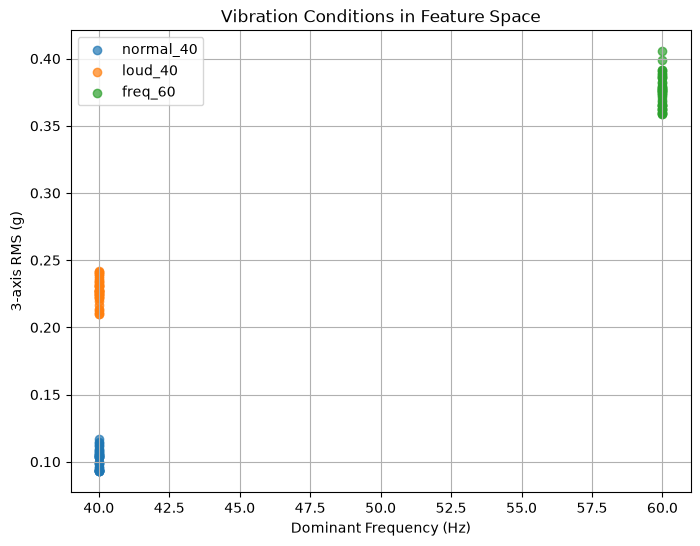

In [23]:
plt.figure(figsize=(8, 6))

for condition in features_df["condition"].unique():

    subset = features_df[
        features_df["condition"] == condition
    ]

    plt.scatter(
        subset["dominant_freq"],
        subset["rms"],
        label=condition,
        alpha=0.7
    )

plt.xlabel("Dominant Frequency (Hz)")
plt.ylabel("3-axis RMS (g)")

plt.title(
    "Vibration Conditions in Feature Space"
)

plt.legend()
plt.grid(True)

plt.show()

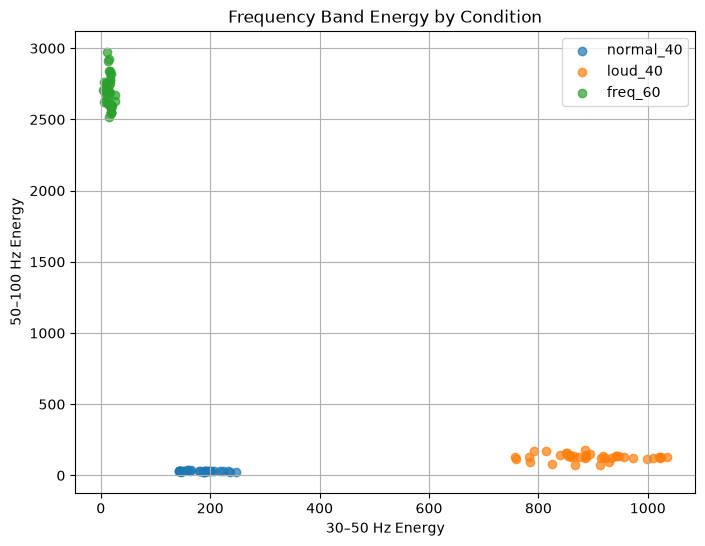

In [24]:
plt.figure(figsize=(8, 6))

for condition in features_df["condition"].unique():

    subset = features_df[
        features_df["condition"] == condition
    ]

    plt.scatter(
        subset["energy_mid"],
        subset["energy_high"],
        label=condition,
        alpha=0.7
    )

plt.xlabel("30–50 Hz Energy")
plt.ylabel("50–100 Hz Energy")

plt.title(
    "Frequency Band Energy by Condition"
)

plt.legend()
plt.grid(True)

plt.show()

In [25]:
print(
    features_df.groupby("condition")[
        "dominant_freq"
    ].value_counts()
)

condition  dominant_freq
freq_60    60.0             40
loud_40    40.0             38
normal_40  40.0             33
Name: count, dtype: int64


In [26]:
# Stationaery vs Tapping

def load_challenge_folder(folder_path, condition):

    tables = []

    folder = Path(folder_path)

    for file_path in sorted(folder.glob("*.csv")):

        df = pd.read_csv(file_path)

        feature_df = extract_recording_features(
            df=df,
            recording_id=file_path.stem,
            condition=condition,
            label=-1,          # unknown / challenge dataset
            trim_seconds=0
        )

        tables.append(feature_df)

    return pd.concat(
        tables,
        ignore_index=True
    )

In [27]:
stationary_df = load_challenge_folder(
    DATA_DIR / "stationary",
    "stationary"
)

tapping_df = load_challenge_folder(
    DATA_DIR / "tapping",
    "tapping"
)

In [28]:
challenge_df = pd.concat(
    [
        stationary_df,
        tapping_df
    ],
    ignore_index=True
)

In [29]:
challenge_df.to_csv(
    processed_dir / "challenge.csv",
    index=False
)

In [30]:
from pathlib import Path
import pandas as pd

def load_challenge_folder(folder_path, condition):
    folder = Path(folder_path)
    tables = []

    for file_path in sorted(folder.glob("*.csv")):
        print(f"Loading {file_path.name}...")
        df = pd.read_csv(file_path)

        feature_df = extract_recording_features(df, 
                                                recording_id=file_path.stem, 
                                                condition=condition,
                                                label=-1,
                                                trim_seconds=0)
        tables.append(feature_df)
    return pd.concat(tables, ignore_index=True)

In [31]:
stationary_df = load_challenge_folder(
    DATA_DIR / "stationary",
    "stationary"
)

tapping_df = load_challenge_folder(
    DATA_DIR / "tapping",
    "tapping"
)

challenge_df = pd.concat(
    [
        stationary_df,
        tapping_df
    ],
    ignore_index=True
)

Loading stationary_1.csv...
Loading stationary_2.csv...
Loading stationary_3.csv...
Loading taps_1.csv...
Loading taps_2.csv...
Loading taps_3.csv...


In [32]:
from pathlib import Path

DATA_DIR = Path("../../data/raw")

freq60_low_tables = []

for file_path in sorted(
    (DATA_DIR / "frq_60_low").glob("*.csv")
):
    df = pd.read_csv(file_path)

    feature_df = extract_recording_features(
        df=df,
        recording_id=file_path.stem,
        condition="freq_60_low",
        label=1,
        trim_seconds=1
    )

    freq60_low_tables.append(feature_df)

freq60_low_df = pd.concat(
    freq60_low_tables,
    ignore_index=True
)

In [33]:
normal40_df = features_df[
    features_df["condition"] == "normal_40"
]

print("NORMAL 40 Hz RMS")
print(
    normal40_df["rms"].describe()
)

print("\nLOW-VOLUME 60 Hz RMS")
print(
    freq60_low_df["rms"].describe()
)

NORMAL 40 Hz RMS
count    33.000000
mean      0.102461
std       0.007238
min       0.092754
25%       0.095478
50%       0.103641
75%       0.106949
max       0.116593
Name: rms, dtype: float64

LOW-VOLUME 60 Hz RMS
count    39.000000
mean      0.335122
std       0.107785
min       0.187779
25%       0.199173
50%       0.405011
75%       0.410595
max       0.440475
Name: rms, dtype: float64


In [34]:
print(
    "\n40 Hz:",
    normal40_df["rms"].min(),
    "to",
    normal40_df["rms"].max()
)

print(
    "60 Hz low:",
    freq60_low_df["rms"].min(),
    "to",
    freq60_low_df["rms"].max()
)


40 Hz: 0.09275417027422819 to 0.1165927922067126
60 Hz low: 0.18777922817591736 to 0.44047478696908743


In [35]:
print(
    freq60_low_df[
        [
            "recording_id",
            "window",
            "rms",
            "dominant_freq",
            "energy_mid",
            "energy_high"
        ]
    ]
)

     recording_id  window       rms  dominant_freq  energy_mid  energy_high
0     freq_60_low       0  0.406827           60.0   28.495984  2920.425202
1     freq_60_low       1  0.402998           60.0   19.798010  2879.903424
2     freq_60_low       2  0.405694           60.0   17.394548  2911.095641
3     freq_60_low       3  0.404829           60.0   20.964732  2907.906231
4     freq_60_low       4  0.406353           60.0   18.971423  2929.955329
5     freq_60_low       5  0.406772           60.0   20.462016  2925.340097
6     freq_60_low       6  0.405011           60.0   19.289224  2900.204095
7     freq_60_low       7  0.404987           60.0   22.052420  2907.724209
8     freq_60_low       8  0.406945           60.0   35.190189  2915.337101
9     freq_60_low       9  0.408809           60.0   43.731005  2915.551445
10    freq_60_low      10  0.409431           60.0   43.583747  2925.239958
11    freq_60_low      11  0.408198           60.0   28.277173  2941.913179
12    freq_6